## Data project

## Task 1.1

In [1]:
# Import packages

# requests is used to retrieve data from statistics Denmark's API.
import requests

# pandas is used to manipulate and store the data
import pandas as pd

# matplotlib is used to visualize the data
import matplotlib.pyplot as plt

# StringIO is used to read the CSV data from the API response into a pandas DataFrame.
from io import StringIO

In [2]:
# Import data on the gini coefficient in Denmark from tabel IFOR41 from Statistics Denmark's API.

# URL for Statistics Denmark's API
url = "https://api.statbank.dk/v1/data"

# API query:
# ULLIG = 70 selects the Gini coefficient
# KOMMUNEDK = 000 selects all of Denmark
# Tid = * selects all available years

query_gini = {
    "table": "IFOR41",
   "format": "CSV",
   "variables": [
      {
         "code": "ULLIG",
         "values": ["70"]
      },
      {
         "code": "KOMMUNEDK",
         "values": ["000"]
      },
      {
         "code": "Tid",
         "values": ["*"]
      }
   ]
}

# send the request to Statistics Denmark
response_gini = requests.post(url, json=query_gini)
# Raise an error if the request was unsuccessful
response_gini.raise_for_status()

# Convert the response to a pandas DataFrame
df_gini = pd.read_csv(
    StringIO(response_gini.text),
    sep=";",
    decimal=",",
)

# Display the imported Gini data
print(df_gini)



               ULLIG    KOMMUNEDK   TID  INDHOLD
0   Gini-koefficient  Hele landet  1987    22.07
1   Gini-koefficient  Hele landet  1988    22.06
2   Gini-koefficient  Hele landet  1989    21.93
3   Gini-koefficient  Hele landet  1990    22.16
4   Gini-koefficient  Hele landet  1991    21.99
5   Gini-koefficient  Hele landet  1992    22.34
6   Gini-koefficient  Hele landet  1993    22.79
7   Gini-koefficient  Hele landet  1994    22.50
8   Gini-koefficient  Hele landet  1995    22.41
9   Gini-koefficient  Hele landet  1996    22.83
10  Gini-koefficient  Hele landet  1997    23.47
11  Gini-koefficient  Hele landet  1998    23.81
12  Gini-koefficient  Hele landet  1999    23.83
13  Gini-koefficient  Hele landet  2000    24.38
14  Gini-koefficient  Hele landet  2001    24.40
15  Gini-koefficient  Hele landet  2002    24.03
16  Gini-koefficient  Hele landet  2003    24.14
17  Gini-koefficient  Hele landet  2004    24.68
18  Gini-koefficient  Hele landet  2005    25.66
19  Gini-koefficient

In [3]:
# Import income by decile from table IFOR32

# We import all 10 deciles because the top 10% income share must be calculated relative to total income across all deciles.
query_deciles = {
    "table": "IFOR32",
   "format": "CSV",
   "variables": [
      {
         "code": "DECILGEN",
         "values": ["*"]
      },
      {
         "code": "KOMMUNEDK",
         "values": ["000"]
      },
      {
         "code": "Tid",
         "values": ["*"]
      }
   ]
}

# Send the request to Statistics Denmark
response_deciles = requests.post(url, json=query_deciles)
# Raise an error if the request was unsuccessful
response_deciles.raise_for_status()

# Convert the response to a pandas DataFrame
df_deciles = pd.read_csv(
    StringIO(response_deciles.text),
    sep=";",
    decimal=","
)

# Display the imported decile data
print(df_deciles)

      DECILGEN    KOMMUNEDK   TID  INDHOLD
0     1. decil  Hele landet  1987    31418
1     1. decil  Hele landet  1988    32746
2     1. decil  Hele landet  1989    35284
3     1. decil  Hele landet  1990    36480
4     1. decil  Hele landet  1991    40715
..         ...          ...   ...      ...
375  10. decil  Hele landet  2020   719999
376  10. decil  Hele landet  2021   779827
377  10. decil  Hele landet  2022   769052
378  10. decil  Hele landet  2023   834074
379  10. decil  Hele landet  2024   852980

[380 rows x 4 columns]


In [4]:
# Calculate the top 10% income share

# IFOR32 reports average income within each decile. Since all deciles contain the same number of people, 
# the sum of the ten decile averages is proportional to total income.

total_income = (
    df_deciles
    .groupby("TID")["INDHOLD"]
    .sum()
    .reset_index(name="TOTAL_INCOME")
)

# Select the 10th decile
top10 = df_deciles[
    df_deciles["DECILGEN"] == "10. decil"
].copy()

# Merge the 10th decile with total income
#Validate="1:1" checks that each year appears only once in each dataset.
top10 = top10.merge(
    total_income,
    on="TID",
    validate="1:1"
)

# Calculate the share of total income received by the richest 10%.
top10["TOP10_SHARE"] = (
    top10["INDHOLD"]
    / top10["TOTAL_INCOME"]
    * 100
)




In [5]:
# Merge the two datasets

# Keep only the year and the Gini coefficient columns and rename INDHOLD to GINI for clarity.
gini = df_gini[
    ["TID", "INDHOLD"]
    ].rename(
        columns={"INDHOLD": "GINI"}
    )

# Merge the Gini coefficient with the top 10% income share by year
# so that both measures are stored in the same Dataframe.
inequality = gini.merge(
    top10[["TID", "TOP10_SHARE"]],
        on="TID",
        validate="1:1"
)

# Display the merged dataset
print(inequality)


     TID   GINI  TOP10_SHARE
0   1987  22.07    18.454866
1   1988  22.06    18.428870
2   1989  21.93    18.495170
3   1990  22.16    18.641480
4   1991  21.99    18.668346
5   1992  22.34    18.824050
6   1993  22.79    19.213004
7   1994  22.50    19.082992
8   1995  22.41    19.296649
9   1996  22.83    19.613977
10  1997  23.47    20.212349
11  1998  23.81    20.349233
12  1999  23.83    20.293497
13  2000  24.38    20.810058
14  2001  24.40    20.722210
15  2002  24.03    20.441865
16  2003  24.14    20.406410
17  2004  24.68    20.718309
18  2005  25.66    21.549831
19  2006  26.28    22.251229
20  2007  27.02    22.630255
21  2008  27.94    21.799734
22  2009  26.74    20.933498
23  2010  27.47    21.918315
24  2011  27.68    22.161128
25  2012  27.37    22.264327
26  2013  27.88    22.748373
27  2014  28.33    22.782468
28  2015  28.77    23.451122
29  2016  28.97    23.383232
30  2017  29.32    23.671866
31  2018  29.10    23.381490
32  2019  29.55    24.005495
33  2020  29.7

The purpose of this step is to combine the two inequality measures into one dataset. First, the Gini coefficient data are simplified to contain only the year and the Gini coefficient. The column INDHOLD is renamed to GINI to make the variable easier to identify. The Gini data are then merged with the top 10% income share using TID as the common year variable. This creates one observation per year containing both measures, which allows us to compare them directly and calculate their correlation in the next step.

In [6]:
# Compute the correlation between the Gini coefficient and the top 10% income share over time.

# Calculate the correlation between the Gini coefficient and the top 10% income share.
correlation = inequality["GINI"].corr(inequality["TOP10_SHARE"])

print(
    "correlation between Gini coefficient"  
    "and top 10% income share:",
    # Round the correlation to 3 decimal places for better readability.
    round(correlation, 3)
)

correlation between Gini coefficientand top 10% income share: 0.982


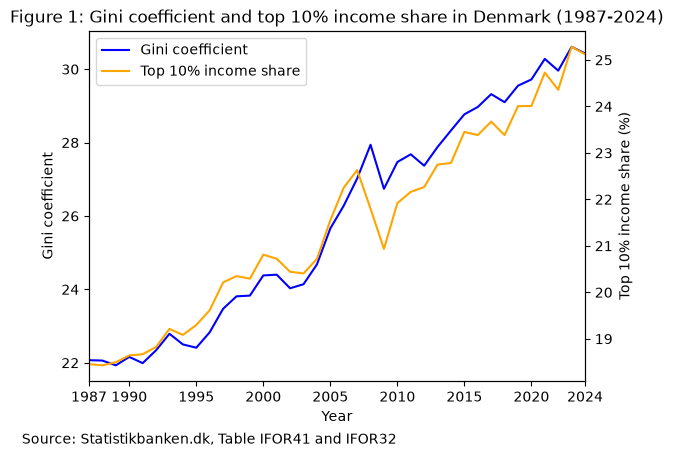

In [7]:
# Produce figure

fig, ax1 = plt.subplots()

# Left y-axis: Gini coefficient
Line1 = ax1.plot(
    inequality["TID"],
    inequality["GINI"],
    label="Gini coefficient",
    color = "blue"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Gini coefficient")


# right y-axis: Top 10% income share
ax2 = ax1.twinx()

line2 = ax2.plot(
    inequality["TID"],
    inequality["TOP10_SHARE"],
    label="Top 10% income share",
    color = "orange"
)

ax2.set_ylabel("Top 10% income share (%)")


# Figure Title
plt.title("Figure 1: Gini coefficient and top 10% income share in Denmark (1987-2024)")


# set the range and selected labels on the x-axis.
ax1.set_xlim(
    inequality["TID"].min(),
    inequality["TID"].max()
)

ax1.set_xticks([1987, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024])

# Combine the legends from the two y-axes into a single legend.
lines = Line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc="upper left")

# Add space for the source text at the bottom of the figure.
plt.subplots_adjust(bottom=0.15)

plt.figtext(
    0.02,
    0.02,
    "Source: Statistikbanken.dk, Table IFOR41 and IFOR32",
    ha="left"
)


plt.show()



Figure 1 shows a clear increase in income equality in Denmark between 1987 and 2024. The Gini coefficient rises from approximately 22 in 1987 to slightly above 30 in 2024, while the income share recived by the richest 10 percent increases from around 18.5 percent to approximately 25 percent.

The two measures generally follow the same pattern over time. Inequality increased relatively gradually during the 1990s, followed by a stronger increase during the 2000s. Both measures show a noticeable decline around the financial crisis, particularly between 2007 and 2009, before continuing their upward trend. In recent years, both measures have remained high, although there are some short-run fluctuations.

The positive co-movement between the two series is also reflected in their correlation. The correlation coefficient is 0.982, indicating a strong positive relationship between the Gini coefficient and the income share of the richest 10 percent over time.

The measures are closely related but not identical. The Gini coefficient reflects inequality across the entire income distribution, whereas the top 10 percent income share focusses specifically on how much income is concentrated among the richest 10 percent. Differences between the two series may therefor occur when changes take place elsewhere in the income distribution.

## Task 1.2

In [8]:
# Import additional packages needed for the prediction analysis.

# numpy is used for numerical operations, and minimize from scipy.optimize is used to find the coefficients that make the difference
# between the observed and predicted values as small as possible.
import numpy as np
from scipy.optimize import minimize


In [9]:
# Prepare the data for prediction analysis

# Extract the observed Gini coefficient
y = df_gini["INDHOLD"].to_numpy()

# Define t as the number of years since 1987
t = df_gini["TID"].to_numpy() - 1987



In [10]:
# Estimate the linear trend

# Define the sum of squared errors for the linear model
def objective_linear(beta):
    beta0, beta1 = beta

    y_hat = beta0 + beta1 * t

# y contains the observed Gini coefficient, and y_hat contains the predicted Gini coefficient based on the linear model.
    return np.sum((y - y_hat) ** 2)

# Choose initial values for the coefficients
beta_start_linear = np.array([0, 0])

# Estimate the coefficients by minimizing the sum of squared errors
result_linear = minimize(
    objective_linear,
    beta_start_linear
)

beta_linear = result_linear.x

# Display the estimated coefficients for the linear model
print("Linear coefficients from minimize:")
print(beta_linear)



Linear coefficients from minimize:
[21.04275355  0.26354959]


The error is the difference between the observed value and the value predicted by the model.
Where (y) is the observed Gini coefficient and (y hat) is the Gini coefficient predicted by the trend model.
The sum of squared errors is calculated by squaring each of these differences and then adding them together. Squaring the errors ensures that positive and negative deviations do not cancel each other out.
The sum of squared errors therefor measures how closely the estimated trend fits the observed data. A smaller value means that the predicted values are, on average, closer to the observed Gini coefficients. In this task, SciPy is used to find the coefficients that minimize the sum of squared errors.

In [11]:
# Define the sum of squared errors for the quadratic model

def objective_quadratic(beta):
    beta0, beta1, beta2 = beta

    y_hat = beta0 + beta1 * t + beta2 * t ** 2

# y contains the observed Gini coefficient, and y_hat contains the predicted Gini coefficient based on the quadratic model.
    return np.sum((y - y_hat) ** 2)

# Choose initial values for the coefficients before the optimization process begins.
beta_start_quadratic = np.array([0, 0, 0])

# Estimate the coefficients by minimizing the sum of squared errors
result_quadratic = minimize(
    objective_quadratic,
    beta_start_quadratic
)

beta_quadratic = result_quadratic.x

# Display the estimated coefficients for the quadratic model
print("Quadratic coefficients from minimize:")
print(beta_quadratic)


Quadratic coefficients from minimize:
[2.13041867e+01 2.19975902e-01 1.17767450e-03]


In [12]:
# Check the results using np.polyfit.

# Estimate the same trends using np.polyfit.
polyfit_linear = np.polyfit(t, y, 1)
polyfit_quadratic = np.polyfit(t, y, 2)

# Reverse the order of the coefficients from np.polyfit to make them directly comparable with the minimize estimates.
print("Linear coefficients:")
print("Minimize:", beta_linear)
print("Polyfit:", polyfit_linear[::-1])

# \n adds a blank line before the quadratic results to make the output easier to read.
print("\nQuadratic coefficients:")
print("Minimize:", beta_quadratic)
print("Polyfit:", polyfit_quadratic[::-1])


Linear coefficients:
Minimize: [21.04275355  0.26354959]
Polyfit: [21.04275304  0.26354962]

Quadratic coefficients:
Minimize: [2.13041867e+01 2.19975902e-01 1.17767450e-03]
Polyfit: [2.13042004e+01 2.19975061e-01 1.17769085e-03]


The coefficients obtained from minimize and np.polyfit are virtually identical. This confirms that the minimization problem has been implemented correctly.

In [13]:
# Predict the Gini coefficient in 2030 and 2040

# Convert 2030 and 2040 into years since 1987
t_2030 = 2030 - 1987
t_2040 = 2040 - 1987

# Linear predictions. Insert the values of t_2030 and t_2040 into the linear model to predict the Gini coefficient for those years.
gini_2030_linear = (
    beta_linear[0] + beta_linear[1] * t_2030
)
gini_2040_linear = (
    beta_linear[0] + beta_linear[1] * t_2040
)

# Quadratic predictions. Insert the values of t_2030 and t_2040 into the quadratic model to predict the Gini coefficient for those years.
gini_2030_quadratic = (
    beta_quadratic[0] + beta_quadratic[1] * t_2030 + beta_quadratic[2] * t_2030 ** 2
)
gini_2040_quadratic = (
    beta_quadratic[0] + beta_quadratic[1] * t_2040 + beta_quadratic[2] * t_2040 ** 2
)

# Display the predictions and round them to two decimal places for better readability.
print("Predictions")
print("Linear prediction for 2030:", round(gini_2030_linear, 2))
print("Linear prediction for 2040:", round(gini_2040_linear, 2))
print("Quadratic prediction for 2030:", round(gini_2030_quadratic, 2))
print("Quadratic prediction for 2040:", round(gini_2040_quadratic, 2))

Predictions
Linear prediction for 2030: 32.38
Linear prediction for 2040: 35.01
Quadratic prediction for 2030: 32.94
Quadratic prediction for 2040: 36.27


In [14]:
# Create fitted and predicted values for plotting

# Create a sequence of years from 1987 to 2040
years_plot = np.arange(1987, 2041)

# Convert the years into years since 1987
t_plot = years_plot - 1987


# Linear fitted and predicted values
gini_linear = (
    beta_linear[0]
    + beta_linear[1] * t_plot
)


# Quadratic fitted and predicted values
gini_quadratic = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_plot
    + beta_quadratic[2] * t_plot**2
)

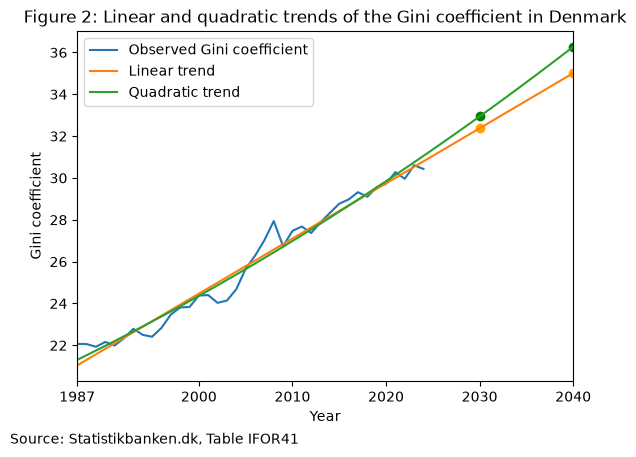

In [15]:
# Create figure 2

# Plot the observed Gini coefficient
plt.plot(
    df_gini["TID"],
    df_gini["INDHOLD"],
    label="Observed Gini coefficient"
)

# Plot the linear trend
plt.plot(
    years_plot,
    gini_linear,
    label="Linear trend"
)

# Plot the quadratic trend
plt.plot(
    years_plot,
    gini_quadratic,
    label="Quadratic trend"
)

# Mark the predictions for 2030 and 2040
plt.scatter(
    [2030, 2040],
    [gini_2030_linear, gini_2040_linear],
    color = "orange"
)

plt.scatter(
    [2030, 2040],
    [gini_2030_quadratic, gini_2040_quadratic],
    color = "green"
)


# Add labels and title
plt.xlabel("Year")
plt.ylabel("Gini coefficient")

plt.title(
    "Figure 2: Linear and quadratic trends of the Gini coefficient in Denmark"
)

# Set the x-axis
plt.xticks(
    [1987, 2000, 2010, 2020, 2030, 2040]
)

plt.xlim(1987, 2040)

# Display the legend
plt.legend()

# Add space for the source
plt.subplots_adjust(bottom=0.15)

# Add source
plt.figtext(
    0.02,
    0.02,
    "Source: Statistikbanken.dk, Table IFOR41",
    ha="left"
)

plt.show()

Both specifications fit the historical data reasonably well, as they capture the overall upward trend in the Gini coefficient. However, neither model captures the short-run fluctuations in the observed data. The quadratic trend follows the historical development slightly more closely because it allows the slope to change over time, whereas the linear trend assumes a constant increase.

The predictions are fairly similar in 2030 but differ more in 2040. The linear model predicts a Gini coefficient of 32.38 in 2030 and 35.01 in 2040, while the quadratic model predicts 32.94 and 36.27, respectively. Thus, the difference between the models is 0.56 points in 2030 and 1.26 points in 2040.

The predictions should be interpreted with caution. Both models simply extrapolate historical trends and do not account for future changes in taxation, transfers, labour-market conditions, economic shocks or other factors that may affect income inequality. The quadratic model fits the historical trend slightly better, but its curvature also makes long-run predictions more sensitive. Therefore, neither model should be treated as a precise forecast, especially for 2040.


## Task 1.3

In [16]:
# Import Gini data for all municipalities in Denmark.

# Import the Gini coefficient for all municipalities and all years
query_gini_municipalities = {
    "table": "IFOR41",
    "format": "CSV",
    "variables": [
        {
            "code": "ULLIG",
            "values": ["70"]
        },
        {
            "code": "KOMMUNEDK",
            "values": ["*"]
        },
        {
            "code": "Tid",
            "values": ["*"]
        }
    ]
}

response_gini_municipalities = requests.post(
    url,
    json=query_gini_municipalities
)

df_gini_municipalities = pd.read_csv(
    StringIO(response_gini_municipalities.text),
    sep=";",
    decimal=","
)

# Remove the observation for Denmark as a whole
df_gini_municipalities = df_gini_municipalities[
    df_gini_municipalities["KOMMUNEDK"] != "Hele landet"
].copy()

# Display the imported data
print(df_gini_municipalities)


                 ULLIG  KOMMUNEDK   TID  INDHOLD
38    Gini-koefficient  København  1987    23.05
39    Gini-koefficient  København  1988    23.09
40    Gini-koefficient  København  1989    23.06
41    Gini-koefficient  København  1990    23.44
42    Gini-koefficient  København  1991    23.23
...                ...        ...   ...      ...
3757  Gini-koefficient    Aalborg  2020    29.12
3758  Gini-koefficient    Aalborg  2021    29.10
3759  Gini-koefficient    Aalborg  2022    29.04
3760  Gini-koefficient    Aalborg  2023    28.65
3761  Gini-koefficient    Aalborg  2024    28.59

[3724 rows x 4 columns]


The Gini coefficient is imported for all municipalities and all available years. The observation for Denmark as a whole is removed because the analysis in this section focuses on differences across municipalities.

In [17]:
# Import decile income data for all municipalities in Denmark.


# Import average income for all ten deciles,
# all municipalities and all available years
query_decile_municipalities = {
    "table": "IFOR32",
    "format": "CSV",
    "variables": [
        {
            "code": "DECILGEN",
            "values": ["*"]
        },
        {
            "code": "KOMMUNEDK",
            "values": ["*"]
        },
        {
            "code": "Tid",
            "values": ["*"]
        }
    ]
}

response_decile_municipalities = requests.post(
    url,
    json=query_decile_municipalities
)

df_decile_municipalities = pd.read_csv(
    StringIO(response_decile_municipalities.text),
    sep=";",
    decimal=","
)

# Remove the observation for Denmark as a whole
df_decile_municipalities = df_decile_municipalities[
    df_decile_municipalities["KOMMUNEDK"] != "Hele landet"
].copy()

# Display the imported data
print(df_decile_municipalities)



        DECILGEN  KOMMUNEDK   TID  INDHOLD
38      1. decil  København  1987    29451
39      1. decil  København  1988    30233
40      1. decil  København  1989    30219
41      1. decil  København  1990    30474
42      1. decil  København  1991    32935
...          ...        ...   ...      ...
37615  10. decil    Aalborg  2020   631707
37616  10. decil    Aalborg  2021   664032
37617  10. decil    Aalborg  2022   675088
37618  10. decil    Aalborg  2023   698292
37619  10. decil    Aalborg  2024   730961

[37240 rows x 4 columns]


The decile data are imported for all municipalities. All ten deciles are required because the income share of the richest 10 percent must be calculated relative to the total income across all deciles.

In [18]:
# Calculate the top 10% income share for each municipality

# Sum the average income across all ten deciles
# for each municipality and year
total_income_municipalities = (
    df_decile_municipalities
    .groupby(["KOMMUNEDK", "TID"])["INDHOLD"]
    .sum()
    .reset_index(name="TOTAL_INCOME")
)

# Select the richest 10%, i.e. the 10th decile
top10_municipalities = df_decile_municipalities[
    df_decile_municipalities["DECILGEN"] == "10. decil"
].copy()

# Merge the 10th-decile income with total income
# for the same municipality and year
top10_municipalities = top10_municipalities.merge(
    total_income_municipalities,
    on=["KOMMUNEDK", "TID"],
    validate="1:1"
)

# Calculate the income share of the richest 10 percent
top10_municipalities["TOP10_SHARE"] = (
    top10_municipalities["INDHOLD"]
    / top10_municipalities["TOTAL_INCOME"]
    * 100
)

# Display the calculated income shares
print(
    top10_municipalities[
        ["KOMMUNEDK", "TID", "TOP10_SHARE"]
    ]
)

      KOMMUNEDK   TID  TOP10_SHARE
0     København  1987    18.382664
1     København  1988    18.347885
2     København  1989    18.320942
3     København  1990    18.581864
4     København  1991    18.716867
...         ...   ...          ...
3719    Aalborg  2020    22.812249
3720    Aalborg  2021    23.010645
3721    Aalborg  2022    23.105612
3722    Aalborg  2023    23.064925
3723    Aalborg  2024    23.214117

[3724 rows x 3 columns]


For each municipality and year, the top 10% income share is calculated as the average income of the 10th decile divided by the sum of average incomes across all ten deciles. Since all deciles contain the same number of people, this corresponds to the share of total income received by the richest 10 percent.

In [19]:
# Merge the Gini coefficient and the top 10% income share for each municipality

# Keep only municipality, year and Gini coefficient
gini_municipalities = df_gini_municipalities[
    ["KOMMUNEDK", "TID", "INDHOLD"]
].rename(
    columns={"INDHOLD": "GINI"}
)

# Merge Gini with the top 10% income share
municipality_inequality = gini_municipalities.merge(
    top10_municipalities[
        ["KOMMUNEDK", "TID", "TOP10_SHARE"]
    ],
    on=["KOMMUNEDK", "TID"],
    validate="1:1"
)

# Display the merged dataset
print(municipality_inequality)

      KOMMUNEDK   TID   GINI  TOP10_SHARE
0     København  1987  23.05    18.382664
1     København  1988  23.09    18.347885
2     København  1989  23.06    18.320942
3     København  1990  23.44    18.581864
4     København  1991  23.23    18.716867
...         ...   ...    ...          ...
3719    Aalborg  2020  29.12    22.812249
3720    Aalborg  2021  29.10    23.010645
3721    Aalborg  2022  29.04    23.105612
3722    Aalborg  2023  28.65    23.064925
3723    Aalborg  2024  28.59    23.214117

[3724 rows x 4 columns]


The two inequality measures are merged by municipality and year. Each row now contains the Gini coefficient and the top 10% income share for the same municipality in the same year.

In [ ]:
# Compute the correlation across municipalities

# Select the most recent year in the dataset
latest_year = municipality_inequality["TID"].max()

latest_municipalities = municipality_inequality[
    municipality_inequality["TID"] == latest_year
].copy()

# Calculate the correlation between the Gini coefficient
# and the top 10% income share across municipalities
municipality_correlation = latest_municipalities["GINI"].corr(
    latest_municipalities["TOP10_SHARE"]
)

print(
    f"Correlation across municipalities in {latest_year}:",
    round(municipality_correlation, 3)
)

Correlation across municipalities in 2024: 0.975


The correlation is calculated across municipalities in the most recent year.
The correlation between the Gini coefficient and the top 10% income share across municipalities is 0.975. This indicates a very strong positive relationship: municipalities where the richest 10 percent receive a larger share of total income also tend to have a higher Gini coefficient.

This result is very similar to the correlation of 0.982 found for Denmark over time in Section 1.1. The two measures therefore tell a very similar story both over time for Denmark as a whole and across municipalities. In both cases, a higher concentration of income among the richest 10 percent is closely associated with a higher overall level of income inequality.

In [21]:
# Select the most recent year

# Identify the most recent year available in the dataset
latest_year = df_gini_municipalities["TID"].max()

# Keep only observations from the most recent year
gini_latest = df_gini_municipalities[
    df_gini_municipalities["TID"] == latest_year
].copy()

print("Most recent year:", latest_year)

Most recent year: 2024


The most recent year in the dataset is selected because the task asks us to identify the most and least unequal municipalities based on the latest available data.

In [22]:
# Identify the 10 most and 10 least unequal municipalities

# Select the 10 municipalities with the lowest Gini coefficients
least_unequal = gini_latest.nsmallest(
    10,
    "INDHOLD"
)

# Select the 10 municipalities with the highest Gini coefficients
most_unequal = gini_latest.nlargest(
    10,
    "INDHOLD"
)

# Display the results
print("10 least unequal municipalities:")
print(
    least_unequal[
        ["KOMMUNEDK", "INDHOLD"]
    ]
)

print("\n10 most unequal municipalities:")
print(
    most_unequal[
        ["KOMMUNEDK", "INDHOLD"]
    ]
)


10 least unequal municipalities:
            KOMMUNEDK  INDHOLD
1861  Faaborg-Midtfyn    23.77
759            Egedal    23.85
1139         Bornholm    24.03
1367             Faxe    24.09
949           Halsnæs    24.41
2659         Favrskov    24.41
1823           Assens    24.46
2697        Hedensted    24.58
227       Albertslund    24.66
2811            Odder    24.70

10 most unequal municipalities:
           KOMMUNEDK  INDHOLD
341         Gentofte    49.04
1101       Rudersdal    47.31
2545           Vejen    46.32
1063        Hørsholm    40.07
607   Lyngby-Taarbæk    39.28
113    Frederiksberg    36.54
75         København    34.97
3039          Aarhus    33.43
797      Fredensborg    32.76
987        Helsingør    30.55


The municipalities are ranked according to their Gini coefficient in the most recent year. A lower Gini coefficient indicates a more equal income distribution, while a higher Gini coefficient indicates greater income inequality.

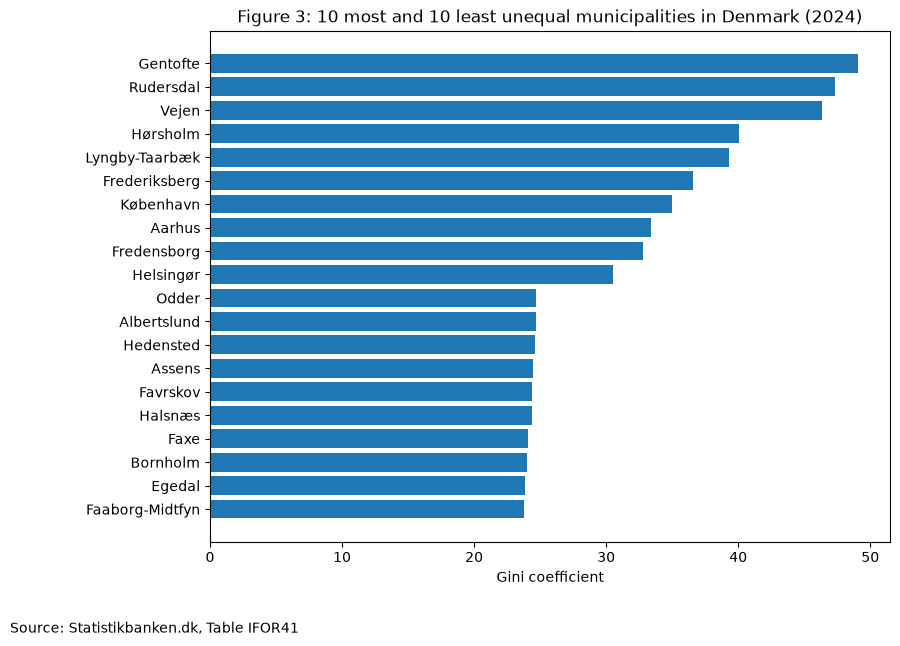

In [23]:

# Produce a figure of the ranking

# Combine the 10 most and 10 least unequal municipalities
ranking = pd.concat([
    least_unequal,
    most_unequal
])

# Sort the municipalities by their Gini coefficient
ranking = ranking.sort_values("INDHOLD")


# Create a horizontal bar chart
plt.figure(figsize=(10, 7))

plt.barh(
    ranking["KOMMUNEDK"],
    ranking["INDHOLD"]
)

plt.xlabel("Gini coefficient")

plt.title(
    f"Figure 3: 10 most and 10 least unequal "
    f"municipalities in Denmark ({latest_year})"
)

# Add space for the source
plt.subplots_adjust(
    left=0.22,
    bottom=0.15
)

# Add source
plt.figtext(
    0.02,
    0.02,
    "Source: Statistikbanken.dk, Table IFOR41",
    ha="left"
)

plt.show()

The figure compares the Gini coefficients of the 10 most and 10 least unequal municipalities in the most recent year. The municipalities are ordered by their Gini coefficient to make the difference between the two groups easier to compare.

In [24]:
# Examine the underlying time series

# Create a list containing the 10 most and 10 least unequal municipalities
selected_municipalities = pd.concat([
    least_unequal,
    most_unequal
])["KOMMUNEDK"].tolist()

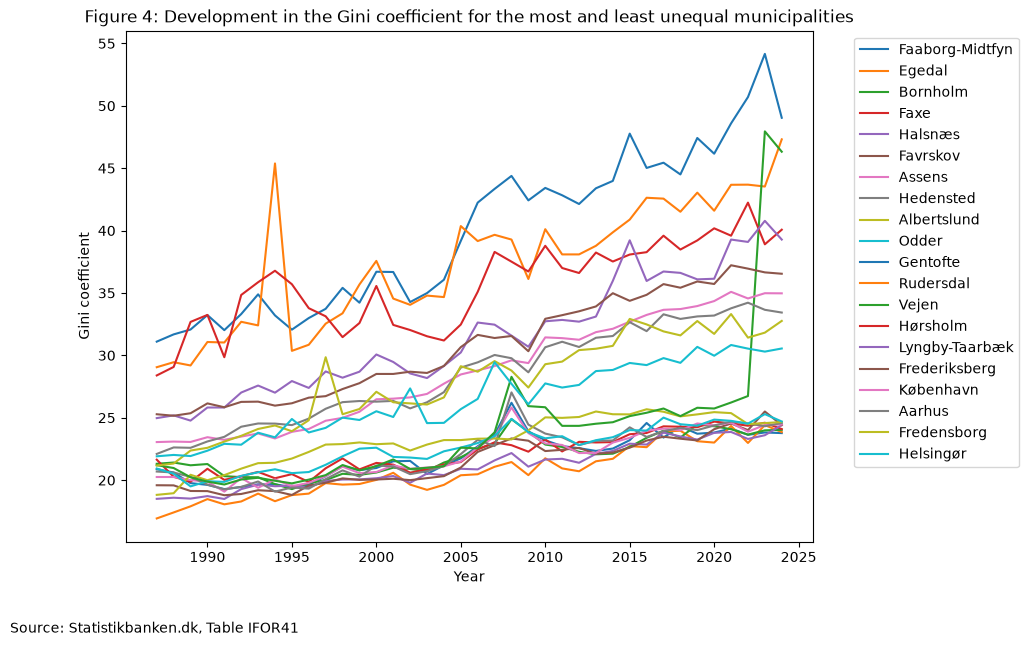

In [25]:
# Plot the historical Gini coefficient for each selected municipality
plt.figure(figsize=(11, 7))

for municipality in selected_municipalities:

    municipality_data = df_gini_municipalities[
        df_gini_municipalities["KOMMUNEDK"] == municipality
    ]

    plt.plot(
        municipality_data["TID"],
        municipality_data["INDHOLD"],
        label=municipality
    )


plt.xlabel("Year")
plt.ylabel("Gini coefficient")

plt.title(
    "Figure 4: Development in the Gini coefficient for the "
    "most and least unequal municipalities"
)

# Place the legend outside the figure to improve readability
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.subplots_adjust(
    right=0.75,
    bottom=0.15
)

plt.figtext(
    0.02,
    0.02,
    "Source: Statistikbanken.dk, Table IFOR41",
    ha="left"
)

plt.show()

The historical series are plotted to examine whether the municipalities' positions in the latest-year ranking reflect persistent differences in inequality or unusually large changes in individual years. This is important because a high or low Gini coefficient in a single year may be influenced by temporary or extreme observations.

In 2024, the 10 most unequal municipalities are Gentofte, Rudersdal, Vejen, Hørsholm, Lyngby-Taarbæk, Frederiksberg, Copenhagen, Aarhus, Fredensborg and Helsingør. The 10 least unequal municipalities are Faaborg-Midtfyn, Egedal, Bornholm, Faxe, Halsnæs, Favrskov, Assens, Hedensted, Albertslund and Odder.

The ranking shows a clear difference between the two groups. The most unequal municipalities generally have Gini coefficients above 30, while the least unequal municipalities are clustered around 24–25. Gentofte has the highest Gini coefficient at just below 50, whereas Faaborg-Midtfyn has the lowest at approximately 24.

However, the underlying time series show that some rankings should be interpreted with caution. In particular, Vejen experiences a very large increase in the Gini coefficient just before 2024, which appears unusual compared with its previous development. Similar temporary spikes can also be seen for some other municipalities. This supports the warning in the assignment that the Gini coefficient in smaller populations can be strongly affected by a single very high income.

Overall, the more unequal municipalities tend to have persistently higher Gini coefficients over time, but some of the extreme 2024 rankings may partly reflect temporary or unusually large observations rather than permanent differences in inequality.


In [26]:
# Calculate the change in the Gini coefficient

# Identify the first and the most recent year in the dataset
first_year = df_gini_municipalities["TID"].min()
latest_year = df_gini_municipalities["TID"].max()

# Extract the Gini coefficient in the first year
gini_first = df_gini_municipalities[
    df_gini_municipalities["TID"] == first_year
][
    ["KOMMUNEDK", "INDHOLD"]
].rename(
    columns={"INDHOLD": "GINI_1987"}
)

# Extract the Gini coefficient in the most recent year
gini_latest = df_gini_municipalities[
    df_gini_municipalities["TID"] == latest_year
][
    ["KOMMUNEDK", "INDHOLD"]
].rename(
    columns={"INDHOLD": "GINI_2024"}
)

# Merge the first and latest observations for each municipality
gini_change = gini_first.merge(
    gini_latest,
    on="KOMMUNEDK",
    validate="1:1"
)

# Calculate the change in the Gini coefficient
gini_change["CHANGE"] = (
    gini_change["GINI_2024"]
    - gini_change["GINI_1987"]
)

print(gini_change)

          KOMMUNEDK  GINI_1987  GINI_2024  CHANGE
0         København      23.05      34.97   11.92
1     Frederiksberg      25.28      36.54   11.26
2            Dragør      21.27      28.86    7.59
3            Tårnby      17.83      24.92    7.09
4       Albertslund      18.82      24.66    5.84
..              ...        ...        ...     ...
93            Morsø      20.85      26.65    5.80
94           Rebild      22.02      25.87    3.85
95          Thisted      21.70      26.42    4.72
96  Vesthimmerlands      21.75      26.40    4.65
97          Aalborg      21.01      28.59    7.58

[98 rows x 4 columns]


The change in the Gini coefficient is measured as the difference between the most recent observation and the first observation for each municipality. A positive value indicates an increase in inequality, while a negative value indicates a decrease.

In [27]:
# Find the largest and smallest change

# Municipality with the largest increase in the Gini coefficient
largest_change = gini_change.loc[
    gini_change["CHANGE"].idxmax()
]

# Municipality with the smallest change
smallest_change = gini_change.loc[
    gini_change["CHANGE"].idxmin()
]

print("Largest change:")
print(largest_change)

print("\nSmallest change:")
print(smallest_change)

Largest change:
KOMMUNEDK    Vejen
GINI_1987     21.2
GINI_2024    46.32
CHANGE       25.12
Name: 65, dtype: object

Smallest change:
KOMMUNEDK     Fanø
GINI_1987    25.67
GINI_2024    26.34
CHANGE        0.67
Name: 58, dtype: object


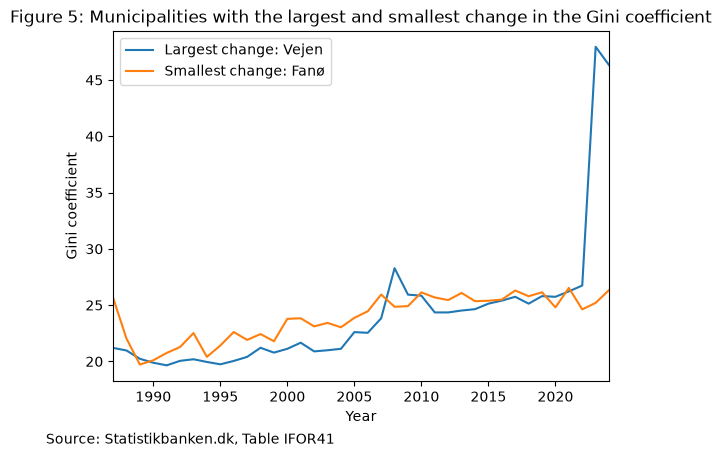

In [28]:
# Plot the underlying time series

# Store the names of the two municipalities
municipality_largest = largest_change["KOMMUNEDK"]
municipality_smallest = smallest_change["KOMMUNEDK"]

# Extract their full historical series
largest_series = df_gini_municipalities[
    df_gini_municipalities["KOMMUNEDK"] == municipality_largest
]

smallest_series = df_gini_municipalities[
    df_gini_municipalities["KOMMUNEDK"] == municipality_smallest
]

# Plot both time series
plt.plot(
    largest_series["TID"],
    largest_series["INDHOLD"],
    label=f"Largest change: {municipality_largest}"
)

plt.plot(
    smallest_series["TID"],
    smallest_series["INDHOLD"],
    label=f"Smallest change: {municipality_smallest}"
)

plt.xlabel("Year")
plt.ylabel("Gini coefficient")

plt.title(
    "Figure 5: Municipalities with the largest and smallest "
    "change in the Gini coefficient"
)

plt.xlim(first_year, latest_year)

plt.legend()

plt.subplots_adjust(bottom=0.15)

plt.figtext(
    0.02,
    0.02,
    "Source: Statistikbanken.dk, Table IFOR41",
    ha="left"
)

plt.show()

The full time series are plotted to examine whether the calculated changes reflect a persistent development or are driven by unusually large observations in individual years.

Vejen has experienced the largest increase in the Gini coefficient over the period, rising from 21.20 in 1987 to 46.32 in 2024. This corresponds to an increase of 25.12 Gini points. Fanø has experienced the smallest change, increasing only from 25.67 to 26.34, corresponding to a change of 0.67 points.

However, the underlying time series show that Vejen’s result should be interpreted with caution. For most of the period, Vejen’s Gini coefficient remained relatively close to the mid-20s, before increasing sharply in the final years. This suggests that the very large measured change is driven mainly by an extreme recent observation rather than by a gradual long-run increase in inequality.

Fanø, in contrast, shows a much more stable development over time. Although there are some short-run fluctuations, the Gini coefficient in 2024 is close to its 1987 level. The comparison therefore illustrates the warning in the assignment: especially in smaller municipalities, the Gini coefficient can be highly sensitive to unusually large individual incomes.


## Task 1.4

## Do municipalities with a larger increase in the share of residents with a long higher education also experience a larger change in income inequality?

In [29]:
# Import education data from HFUDD11

# Import the total population and the number of people with a long higher education (LVU) for all areas and years
query_education = {
    "table": "HFUDD11",
    "format": "CSV",
    "variables": [
        {
            "code": "BOPOMR",
            "values": ["*"]
        },
        {
            "code": "HERKOMST",
            "values": ["TOT"]
        },
        {
            "code": "HFUDD",
            "values": ["TOT", "H70"]
        },
        {
            "code": "ALDER",
            "values": ["TOT"]
        },
        {
            "code": "KØN",
            "values": ["TOT"]
        },
        {
            "code": "Tid",
            "values": ["*"]
        }
    ]
}

response_education = requests.post(
    url,
    json=query_education
)

response_education.raise_for_status()

df_education = pd.read_csv(
    StringIO(response_education.text),
    sep=";",
    decimal=","
)

print(df_education)

           BOPOMR HERKOMST                                    HFUDD  \
0     Hele landet    I alt                                    I alt   
1     Hele landet    I alt                                    I alt   
2     Hele landet    I alt                                    I alt   
3     Hele landet    I alt                                    I alt   
4     Hele landet    I alt                                    I alt   
...           ...      ...                                      ...   
3775      Aalborg    I alt  H70 Lange videregående uddannelser, LVU   
3776      Aalborg    I alt  H70 Lange videregående uddannelser, LVU   
3777      Aalborg    I alt  H70 Lange videregående uddannelser, LVU   
3778      Aalborg    I alt  H70 Lange videregående uddannelser, LVU   
3779      Aalborg    I alt  H70 Lange videregående uddannelser, LVU   

            ALDER    KØN   TID  INDHOLD  
0     Alder i alt  I alt  2008  3903627  
1     Alder i alt  I alt  2009  3926254  
2     Alder i alt  I 

Data from HFUDD11 are used to measure the educational composition of each municipality. We import both the total population aged 15–69 and the number of residents whose highest completed education is a long higher education (LVU).

In [30]:

# Keep only the 98 municipalities

# Use the municipalities from the Gini dataset to ensure that
# only the 98 Danish municipalities are included
municipalities = (
    df_gini_municipalities["KOMMUNEDK"]
    .unique()
)

df_education = df_education[
    df_education["BOPOMR"].isin(municipalities)
].copy()

# Check that exactly 98 municipalities remain
print("Number of municipalities:",
      df_education["BOPOMR"].nunique())

Number of municipalities: 98


The education data are restricted to the same 98 municipalities used in the Gini analysis. This excludes Denmark as a whole, the five regions and Christiansø, ensuring that the two datasets contain the same geographical units.

In [31]:

# Calculate the share with a long higher education

# Select the total population
education_total = df_education[
    df_education["HFUDD"] == "I alt"
][
    ["BOPOMR", "TID", "INDHOLD"]
].rename(
    columns={"INDHOLD": "TOTAL_POPULATION"}
)

# Select people with a long higher education (LVU)
education_lvu = df_education[
    df_education["HFUDD"].str.contains(
        "H70 Lange videregående uddannelser",
        na=False
    )
][
    ["BOPOMR", "TID", "INDHOLD"]
].rename(
    columns={"INDHOLD": "LVU"}
)

# Merge the two datasets by municipality and year
education_share = education_total.merge(
    education_lvu,
    on=["BOPOMR", "TID"],
    validate="1:1"
)

# Calculate the share of residents with a long higher education
education_share["LVU_SHARE"] = (
    education_share["LVU"]
    / education_share["TOTAL_POPULATION"]
    * 100
)

print(
    education_share[
        ["BOPOMR", "TID", "LVU_SHARE"]
    ]
)

         BOPOMR   TID  LVU_SHARE
0     København  2008  13.005500
1     København  2009  13.656738
2     København  2010  14.217663
3     København  2011  14.849697
4     København  2012  15.533022
...         ...   ...        ...
1759    Aalborg  2021  11.900699
1760    Aalborg  2022  12.383153
1761    Aalborg  2023  12.816344
1762    Aalborg  2024  13.169197
1763    Aalborg  2025  13.564589

[1764 rows x 3 columns]


The number of residents with a long higher education is divided by the total population aged 15–69 in each municipality. This produces the share of residents with an LVU and makes municipalities of different population sizes comparable.

In [32]:

# Merge education and Gini data

# Rename the municipality variable to match the Gini dataset
education_share = education_share.rename(
    columns={"BOPOMR": "KOMMUNEDK"}
)

# Keep the relevant Gini variables
gini_extension = df_gini_municipalities[
    ["KOMMUNEDK", "TID", "INDHOLD"]
].rename(
    columns={"INDHOLD": "GINI"}
)

# Merge education and Gini data by municipality and year
extension_data = gini_extension.merge(
    education_share[
        ["KOMMUNEDK", "TID", "LVU_SHARE"]
    ],
    on=["KOMMUNEDK", "TID"],
    validate="1:1"
)

print(extension_data)

      KOMMUNEDK   TID   GINI  LVU_SHARE
0     København  2008  29.60  13.005500
1     København  2009  29.38  13.656738
2     København  2010  31.44  14.217663
3     København  2011  31.38  14.849697
4     København  2012  31.25  15.533022
...         ...   ...    ...        ...
1661    Aalborg  2020  29.12  11.467514
1662    Aalborg  2021  29.10  11.900699
1663    Aalborg  2022  29.04  12.383153
1664    Aalborg  2023  28.65  12.816344
1665    Aalborg  2024  28.59  13.169197

[1666 rows x 4 columns]


The education data are merged with the Gini data by municipality and year. Each observation now contains both the Gini coefficient and the share of residents with a long higher education.

In [33]:

# Calculate changes over the common time period

# Identify the first and latest year available in both datasets
first_year_extension = extension_data["TID"].min()
latest_year_extension = extension_data["TID"].max()

print("First common year:", first_year_extension)
print("Latest common year:", latest_year_extension)


# Select observations from the first year
extension_first = extension_data[
    extension_data["TID"] == first_year_extension
][
    ["KOMMUNEDK", "GINI", "LVU_SHARE"]
].rename(
    columns={
        "GINI": "GINI_FIRST",
        "LVU_SHARE": "LVU_SHARE_FIRST"
    }
)

# Select observations from the latest year
extension_latest = extension_data[
    extension_data["TID"] == latest_year_extension
][
    ["KOMMUNEDK", "GINI", "LVU_SHARE"]
].rename(
    columns={
        "GINI": "GINI_LATEST",
        "LVU_SHARE": "LVU_SHARE_LATEST"
    }
)

# Merge the first and latest observations
extension_change = extension_first.merge(
    extension_latest,
    on="KOMMUNEDK",
    validate="1:1"
)

# Calculate the change in both variables
extension_change["GINI_CHANGE"] = (
    extension_change["GINI_LATEST"]
    - extension_change["GINI_FIRST"]
)

extension_change["LVU_SHARE_CHANGE"] = (
    extension_change["LVU_SHARE_LATEST"]
    - extension_change["LVU_SHARE_FIRST"]
)

print(extension_change)

First common year: 2008
Latest common year: 2024
          KOMMUNEDK  GINI_FIRST  LVU_SHARE_FIRST  GINI_LATEST  \
0         København       29.60        13.005500        34.97   
1     Frederiksberg       31.55        18.257633        36.54   
2            Dragør       27.57         8.609924        28.86   
3            Tårnby       21.99         3.421495        24.92   
4       Albertslund       23.26         4.899788        24.66   
..              ...         ...              ...          ...   
93            Morsø       31.02         2.081406        26.65   
94           Rebild       30.90         5.285519        25.87   
95          Thisted       29.51         2.475263        26.42   
96  Vesthimmerlands       30.58         2.073750        26.40   
97          Aalborg       27.28         6.655155        28.59   

    LVU_SHARE_LATEST  GINI_CHANGE  LVU_SHARE_CHANGE  
0          25.155363         5.37         12.149863  
1          28.842973         4.99         10.585340  
2       

Changes are calculated between the first and latest years for which both Gini and education data are available. GINI_CHANGE measures the change in income inequality, while LVU_SHARE_CHANGE measures the change in the share of residents with a long higher education in percentage points.

In [34]:

# Compute the correlation

# Calculate the correlation between the change in the LVU share
# and the change in the Gini coefficient across municipalities
education_gini_correlation = (
    extension_change["LVU_SHARE_CHANGE"]
    .corr(extension_change["GINI_CHANGE"])
)

print(
    "Correlation between change in LVU share and change in Gini:",
    round(education_gini_correlation, 3)
)

Correlation between change in LVU share and change in Gini: 0.471


The correlation measures whether municipalities with a larger increase in the share of highly educated residents also tend to experience a larger increase in income inequality.

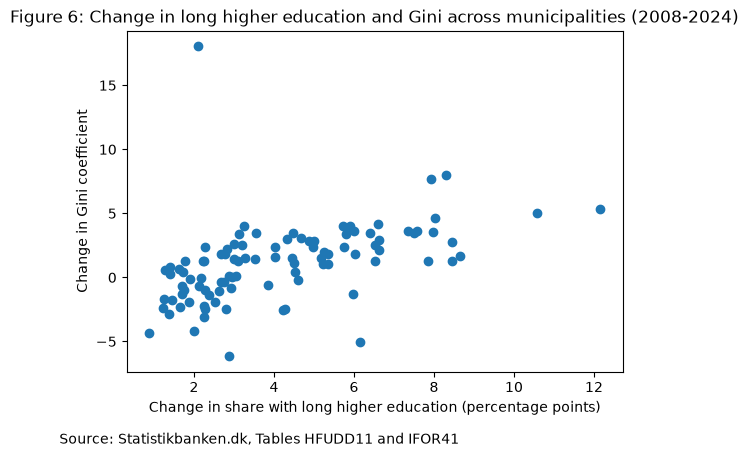

In [35]:

# Produce Figure 6

# Create a scatter plot with one observation for each municipality
plt.scatter(
    extension_change["LVU_SHARE_CHANGE"],
    extension_change["GINI_CHANGE"]
)

# Add axis labels
plt.xlabel(
    "Change in share with long higher education (percentage points)"
)

plt.ylabel(
    "Change in Gini coefficient"
)

# Add title
plt.title(
    f"Figure 6: Change in long higher education and Gini "
    f"across municipalities ({first_year_extension}-{latest_year_extension})"
)

# Add source
plt.subplots_adjust(bottom=0.17)

plt.figtext(
    0.02,
    0.02,
    "Source: Statistikbanken.dk, Tables HFUDD11 and IFOR41",
    ha="left"
)

plt.show()

The scatter plot suggests a moderate positive relatiosnhip between the increase in the share of residents with a long higher education and the change in the Gini coefficient across municipalities between 2008 and 2024. Muncipialities with larger increase in the share of highly educated residents tend, on average, to also experience a larger increase in income inequality.

This is supported by the correlation coefficient of 0.471, which indicates a positive but clear weaker relationship than the correlations found earlier between the Gini coefficient and the top 10% income share. In section 1.1, the correlation over time for Denmark as a whole was 0.982, and in Section 1.3 the correlation across municipalities was 0.975. These very high correlations showed that the Gini coefficient and the top 10% income share capture closely related aspects of income inequality.

By contrast, the relationship between higher education and inequality is much less direct. The correlation of 0.471 suggests that educational composition may be associated with changes in inequality, but it does not explain them to the same extent as the top 10% income share. The scatter plot also shows considerable variation around the overall positive pattern, including several outliers.

The result should therefore be interpreted as an association rather than a causal relationship. Municipalities with a growing share of highly educated residents may also differ in income levels, labour-market opportunities, housing markets and population composition, which can all influence the Gini coefficient.